In [15]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Etapa 1 – Carregar os dados
Carregue o arquivo base_credito.csv utilizando Python. Apresente a tabela carregada
no programa.

In [16]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/IA/base_credito.csv")

#Carregar os dados

#Apresentando a tabela
display(df)

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54
...,...,...,...,...,...
49995,38,8818.70,760,94.72,47301.48
49996,55,11501.96,728,75.57,50408.79
49997,46,7374.09,479,91.25,22142.20
49998,29,2290.91,739,95.07,24040.33


In [17]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1fyQtv4DHwBXlYQQh10ZFtr90cf3b0RrKSub-Lh4CtfY/edit#gid=0


Etapa 2 – Conhecer os dados
Identifique:
• quais são as variáveis utilizadas como entrada;
• qual é a variável que deverá ser prevista;
• quais tipos de dados estão presentes na base.
Explique brevemente o significado de cada variável.



*   Total de registros: 50.000 linhas
*   Total de colunas: 5 variáveis



*   Item da lista
*   Item da lista





In [18]:
display(df.columns[:])
print('///////////')
display(df.columns[:-1])
print('///////////')

## Mostra os tipos de dados, quantidades de linhas e colunas e a quantidade de valores não nulos.
print('Informações:')
df.info()

## Mostra estatísticas
print('///////////')
print('Estatísticas:')
df.describe()

Index(['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos',
       'valor_emprestimo'],
      dtype='object')

///////////


Index(['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos'], dtype='object')

///////////
Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB
///////////
Estatísticas:


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


Variáveis de entrada:


*   'idade' Tipo de dado: inteiro (int64) - Descreve a idade do cliente
*   'renda_mensal' Tipo de dado: decimal (float64) - Descreve o rendimento mensal do cliente
*   'score_credito' Tipo de dado: inteiro (int64) - O Score de crédito do cliente (0 a 1000).
*   'historico_pagamentos' Tipo de dado: decimal (float64) - Quantidade de pagamentos em dia do cliente (0 a 100%).

Essas são as variáveis que descrevem o objeto e serão utilizadas para que o algoritmo possa fazer previsões e cálculos.

Variável de saída:

*   'valor_emprestimo' Tipo de dado: decimal (float64) - Valor em reais com dois dígitos decimais, indica o valor do empréstimo aprovado.



Essa é a variável que será prevista, o algoritmo recebe uma série de informações para identificar padrões que possam ser utilizados para fornecer resultados.

Etapa 3 – Analisar os dados
Faça uma análise inicial dos dados. Apresente pelo menos um gráfico que ajude a visualizar
a relação entre uma das variáveis de entrada e o valor do empréstimo. Descreva brevemente
o comportamento observado.

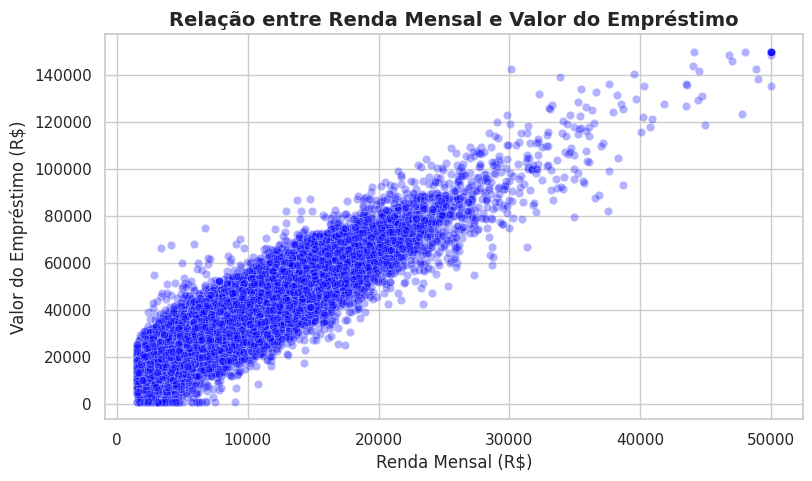

In [19]:
## Visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Cria o gráfico de dispersão
sns.scatterplot(
    data=df,
    x='renda_mensal',
    y='valor_emprestimo',
    alpha=0.3,
    color='blue'
)
plt.title('Relação entre Renda Mensal e Valor do Empréstimo', fontsize=14, fontweight='bold')
plt.xlabel('Renda Mensal (R$)', fontsize=12)
plt.ylabel('Valor do Empréstimo (R$)', fontsize=12)

plt.show()

O gráfico mostra a relação entre a renda mensal e o valor do empréstimo. A maior parte dos dados se concentram na parte inferior esquerda do gráfico, isso significa que a maioria dos clientes possuem renda mensal entre 0 e 10.000 reais e o valor do seu empréstimo está entre 0 e 20.000 reais. A relação entre a renda mensal e o valor do empréstimo mostra que quanto maior a renda mensal do cliente maior será o valor do seu empréstimo.

Etapa 4– Preparar os dados
Separe os dados em:

*   conjunto de treinamento;
*    conjunto de teste.
Utilize uma divisão adequada e informe qual proporção foi utilizada para cada conjunto.

In [20]:
from sklearn.model_selection import train_test_split

# Separar as variáveis de entrada (X) e a variável alvo (y)
X = df[['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']]
y = df['valor_emprestimo']

# Dividir os dados em conjuntos de treino e teste (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Exibir o tamanho de cada conjunto
print(f"Conjunto de Treinamento: {X_train.shape[0]} amostras (80%)")
print(f"Conjunto de Teste: {X_test.shape[0]} amostras (20%)")

Conjunto de Treinamento: 40000 amostras (80%)
Conjunto de Teste: 10000 amostras (20%)


A divisão 80/20 é uma proporção amplamente adotada em Aprendizado de Máquina Supervisionado. Os 80% garantem um volume robusto de dados para o modelo identificar os padrões entre as características dos clientes e os empréstimos aprovados, enquanto os 20% servem como um conjunto independente para testar se o modelo consegue fazer boas previsões em dados inéditos.
O parâmetro random_state=42 foi utilizado para garantir a reprodutibilidade dos resultados em execuções futuras.

Etapa 5– Treinar o modelo
Utilize um algoritmo de regressão para construir o modelo. O modelo deverá utilizar as
características dos clientes para prever o valor do empréstimo.
Apresente o código utilizado para:

*   criar o modelo;
*   realizar o treinamento;
*   gerar as previsões.

In [21]:
from sklearn.linear_model import LinearRegression

# Criar o modelo
modelo = LinearRegression()

# Realizar o treinamento com os dados de treino
modelo.fit(X_train, y_train)

# Gerar as previsões para o conjunto de teste (X_test)
y_pred = modelo.predict(X_test)

# Exibir os coeficientes aprendidos pelo modelo (opcional)
print("Treinamento concluído com sucesso!")
print(f"Intercepto (termo constante): R$ {modelo.intercept_:.2f}")
print("Coeficientes por variável:")
for col, coef in zip(X.columns, modelo.coef_):
    print(f" - {col}: {coef:.2f}")

Treinamento concluído com sucesso!
Intercepto (termo constante): R$ -39439.69
Coeficientes por variável:
 - idade: 54.71
 - renda_mensal: 2.83
 - score_credito: 60.89
 - historico_pagamentos: 98.91


Algoritmo Escolhido:
Foi utilizado o algoritmo de **Regressão Linear Multiple** da biblioteca scikit-learn.

Etapas do Processo:
1. Criação do Modelo: Instanciamos o objeto LinearRegression().
2. Treinamento: O método .fit(X_train, y_train) foi executado para que o modelo aprenda a relação matemática entre as variáveis de entrada (idade, renda_mensal, score_credito, historico_pagamentos) e a variável de saída (valor_emprestimo).
3. Geração de Previsões: O método .predict(X_test) gerou as estimativas de valores de empréstimo para os 10.000 clientes do conjunto de teste, guardando os resultados na variável y_pred.

Etapa 6– Avaliar o modelo
Avalie o desempenho do modelo utilizando métricas adequadas para regressão. Apresente
pelo menos duas métricas de avaliação. Explique, com suas palavras, o que os valores
encontrados representam.

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cálculo das métricas de avaliação
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Métricas de Avaliação do Modelo ---")
print(f"MAE  (Erro Médio Absoluto): R$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:.2f}")
print(f"R²   (Coeficiente de Determinação): {r2:.4f} ({r2*100:.2f}%)")

--- Métricas de Avaliação do Modelo ---
MAE  (Erro Médio Absoluto): R$ 2985.94
RMSE (Raiz do Erro Quadrático Médio): R$ 4014.17
R²   (Coeficiente de Determinação): 0.9223 (92.23%)


1. MAE (Erro médio absoluto) - 2985.94 R$
Indica o erro médio simples entre as previsões e os valores reais.
As estimativas do modelo erram por volta de 2985.94 para mais ou para menos.

2. RMSE (Raiz do erro quadrático médio) - 4014.17 R$
Penaliza os erros de grande magnitude, eleva os desvios ao quadrado antes de extrair a raiz.
Não existem outliers graves, já que o valor do RMSE está próximo do MAE.

3. R² (Coeficiente de determinação) - 0.923 (92.23%)
Mede a percentagem de variação do valor do empréstimo.
A alta percentagem significa que o modelo consegue explicar a maioria das variações dos valores de empréstimo.

Etapa 7– Comparar valores reais e previstos
Compare os valores reais dos empréstimos com os valores previstos pelo modelo. Apresente
uma tabela ou gráfico contendo exemplos dessa comparação. Analise se as previsões estão
próximas dos valores reais

--- Tabela Comparativa de Exemplos (10 Primeiros Registros) ---


,Valor Real (R$),Valor Previsto (R$),Diferença Absoluta (R$),Erro (%)
0,22268.46,14806.34,7462.12,33.51
1,27457.59,29512.49,2054.90,7.48
2,25451.04,25840.74,389.70,1.53
3,23890.67,21077.52,2813.15,11.78
4,27754.95,27919.31,164.36,0.59
5,12544.92,14530.91,1985.99,15.83
6,28759.01,27385.97,1373.04,4.77
7,46454.49,41011.61,5442.88,11.72
8,43199.01,36525.09,6673.92,15.45
9,34051.39,35786.96,1735.57,5.10


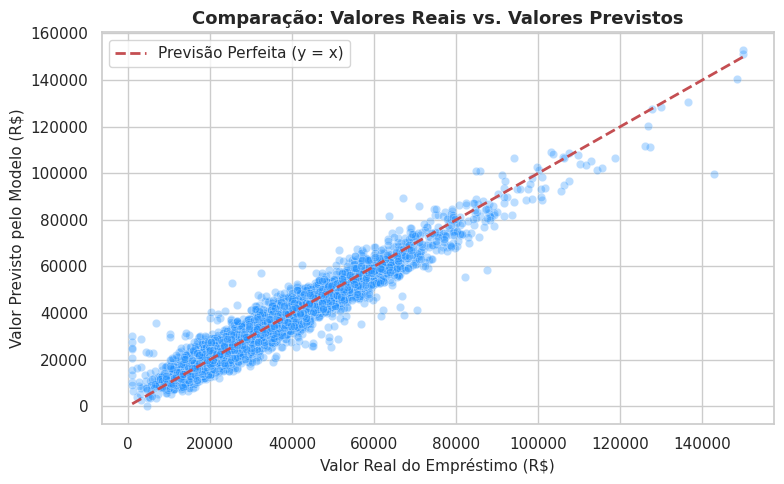

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tabela com os 10 primeiros exemplos do conjunto de teste
df_comparacao = pd.DataFrame({
    'Valor Real (R$)': y_test.values[:10],
    'Valor Previsto (R$)': y_pred[:10],
    'Diferença Absoluta (R$)': np.abs(y_test.values[:10] - y_pred[:10]),
    'Erro (%)': (np.abs(y_test.values[:10] - y_pred[:10]) / y_test.values[:10]) * 100
})

print("--- Tabela Comparativa de Exemplos (10 Primeiros Registros) ---")
display(df_comparacao.round(2))

# Gráfico de dispersão: Valores Reais vs Previstos
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='dodgerblue')

# Linha vermelha tracejada indicando a previsão perfeita (onde Real == Previsto)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Previsão Perfeita (y = x)')

plt.title('Comparação: Valores Reais vs. Valores Previstos', fontsize=13, fontweight='bold')
plt.xlabel('Valor Real do Empréstimo (R$)', fontsize=11)
plt.ylabel('Valor Previsto pelo Modelo (R$)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

As previsões estão próximas dos valores reais na maioria das amostras. Alguns exemplos mostram uma margem de erro inferior a 5%.
No gráfico de dispersão, os pontos azuis concentram-se próximo da linha vermelha, mostrando o acompanhamento da tendência real dos dados.
O modelo ajustou-se bem ao padrão do negócio e apresenta um comportamento consistente.

Etapa 8– Fazer uma previsão
Considere um novo cliente com características criadas por você mesmo.
Apresente:

*   as características do cliente;
*   o valor previsto pelo modelo;
*   uma breve interpretação do resultado.

In [24]:
import pandas as pd

# Novo cliente e suas características
novo_cliente = pd.DataFrame([{
    'idade': 30,
    'renda_mensal': 8500.00,
    'score_credito': 720,
    'historico_pagamentos': 92.50
}])

# Gera a previsão
valor_previsto = modelo.predict(novo_cliente)[0]

# Exibe o resultado
print("Perfil do Novo Cliente:")
print(f"Idade: {novo_cliente['idade'].values[0]} anos")
print(f"Renda Mensal: {novo_cliente['renda_mensal'].values[0]:,.2f}")
print(f"Score de Crédito: {novo_cliente['score_credito'].values[0]} pontos")
print(f"Histórico de Pagamentos: {novo_cliente['historico_pagamentos'].values[0]}%")
print("-------------------")
print(f"Valor do Empréstimo Estimado: R$ {valor_previsto:,.2f}")

Perfil do Novo Cliente:
Idade: 30 anos
Renda Mensal: 8,500.00
Score de Crédito: 720 pontos
Histórico de Pagamentos: 92.5%
-------------------
Valor do Empréstimo Estimado: R$ 39,233.43


O novo cliente possui uma renda mensal acima da média da base (8,500.00 vs. média de 7,542.18), um bom score (720) e um histórico de pagamentos consistente (92,5%).
O modelo estimou uma concessão de crédito de 39,233.43, esse valor está acima da média geral de empréstimos (31,736.16), o que faz sentido se as características do cliente, com menor risco de inadimplência.


Etapa 9– Conclusão
O modelo de regressão apresentou resultados adequados para estimar o valor dos empréstimos? Quais são suas principais limitações?

O modelo de regressão apresentou resultados adequados para estimar o valor dos empréstimos? Quais são suas principais limitações?

Sim, o modelo de regressão apresentou resultados satisfatórios. A margem de erro médio baixa de 2.985,94 e o ajuste de 92,23 significam que o modelo consegue explicar a maioria das variações nos valores de empréstimos com base nas características analisadas.
As limitações do modelo devem ser consideradas, a regressão linear assume uma relação linear entre as variáveis. Na prática, o risco de crédito pode apresentar comportamentos mais complexos.
O modelo não reage sozinho a variações de mercado (como aumento da inflação e mudança na taxa SELIC).